In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score


In [14]:
import pandas as pd
df=pd.read_csv('/content/penguins.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [6]:

import numpy as np
for col in df.select_dtypes(include=np.number).columns:
  df[col]=df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
  df[col]=df[col].fillna(df[col].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   344 non-null    float64
 1   culmen_depth_mm    344 non-null    float64
 2   flipper_length_mm  344 non-null    float64
 3   body_mass_g        344 non-null    float64
 4   sex                344 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [9]:

from sklearn.preprocessing import StandardScaler,LabelEncoder
le_dict={}
for col in df.select_dtypes(include='object').columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_dict[col]=le


In [10]:
x=df.drop('sex',axis=1)
y=df['sex']

In [12]:
scaler=StandardScaler()
x=scaler.fit_transform(x)


In [18]:

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV
pca=PCA()
param_grid = {'n_components':list(range(1,x.shape[1]+1))}
grid_pca = GridSearchCV(pca,param_grid, cv=10)
grid_pca.fit(x)
best_n = grid_pca.best_params_['n_components']
print("best number of components:",best_n)

best number of components: 1


In [19]:
pca=PCA(n_components=best_n)
x=pca.fit_transform(x)

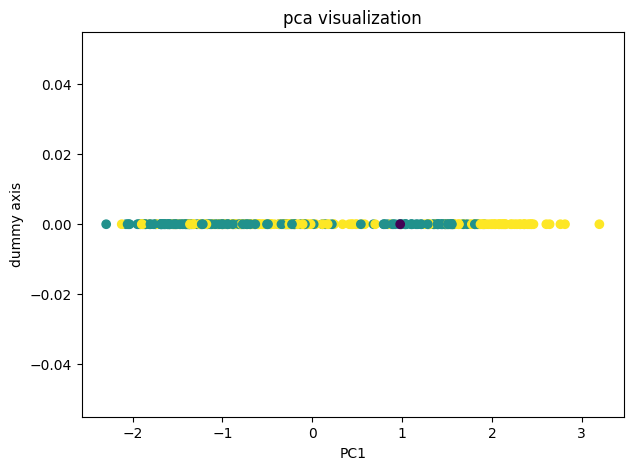

In [25]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7,5))
plt.scatter(x[:,0],np.zeros_like(x[:,0]),c=y)
plt.xlabel('PC1')
plt.ylabel('dummy axis')
plt.title("pca visualization")
plt.show()

In [29]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [35]:

from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
param_grid_dt = {
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5,6],
    'min_samples_leaf':[1,2,3],
    'min_samples_split':[2,3,4,10]
}
grid_dt=GridSearchCV(dt,param_grid_dt,cv=10)
grid_dt.fit(x_train,y_train)
best_model = grid_dt.best_estimator_
print("best parameters:",grid_dt.best_params_)
print("best criterian:",grid_dt.best_params_['criterion'])
print("best depth:",grid_dt.best_params_['max_depth'])

best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
best criterian: entropy
best depth: 5


In [42]:

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
y_pred=best_model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
fl=f1_score(y_test,y_pred, average='weighted')
acc=accuracy_score(y_test,y_pred)
print("accuracy:",acc)
print("confusion matrix:\n",cm)
print("f1 score:",fl)

accuracy: 0.6521739130434783
confusion matrix:
 [[ 0  1  0]
 [ 0 16 14]
 [ 0  9 29]]
f1 score: 0.6427932418270582


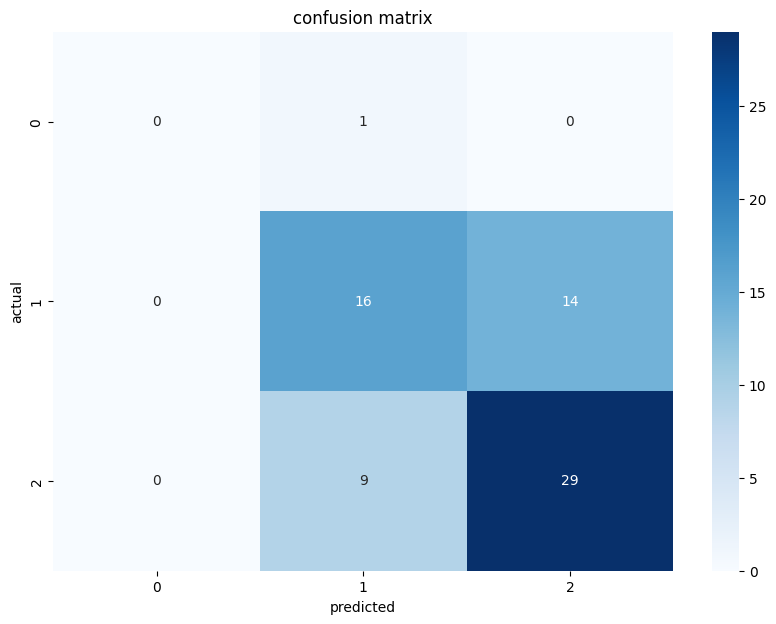

In [43]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()